# Liệu thói quen sinh hoạt có ảnh hưởng gì đến khả năng mắc bệnh trầm cảm không?

Tiến hành đọc dữ liệu để xem trong dữ liệu có những yếu tố thói quen sinh hoạt nào liên quan

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_style("whitegrid")
df = pd.read_csv("data_final.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81991 entries, 0 to 81990
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     81991 non-null  int64  
 1   Name                                   81991 non-null  object 
 2   Gender                                 81991 non-null  object 
 3   Age                                    81991 non-null  float64
 4   City                                   81991 non-null  object 
 5   Working Professional or Student        81991 non-null  object 
 6   Profession                             81990 non-null  object 
 7   Academic Pressure                      81990 non-null  float64
 8   Work Pressure                          81990 non-null  float64
 9   CGPA                                   81990 non-null  float64
 10  Study Satisfaction                     81990 non-null  float64
 11  Jo

Các yếu tố được xem xét bao gồm:
- Thói quen ăn uống (Dietary Habits)
- Thời gian học tập/làm việc (Work/Study Hours)
- Thời lượng ngủ (Sleep Duration)

## Câu hỏi nhỏ
I. Phân tích từng yếu tố đơn lẻ
- Thói quen ăn uống có làm tăng nguy cơ trầm cảm không?
- Số giờ làm/học có liên quan đến trầm cảm không?
- Thời lượng ngủ ảnh hưởng thế nào đến trầm cảm?

II. Phân tích hai yếu tố kết hợp
- Sự kết hợp hai yếu tố sinh hoạt mang lại nguy cơ mắc bệnh Trầm cảm (Depression) lớn hơn đáng kể so với tác động độc lập không?

III. Phân tích ba yếu tố kết hợp
- Càng nhiều thói quen xấu thì nguy cơ trầm cảm có càng cao không?



### I. Phân tích từng yếu tố đơn lẻ

### Câu 1: Thói quen ăn uống có làm tăng nguy cơ trầm cảm không?

Mục tiêu của phân tích này là kiểm tra xem **thói quen ăn uống (Dietary Habits)**
có liên quan đến **tình trạng trầm cảm (Depression)** hay không.

Nếu chế độ ăn không lành mạnh có tỷ lệ trầm cảm cao hơn,
điều đó cho thấy **thói quen ăn uống có thể là một yếu tố ảnh hưởng đến sức khỏe tinh thần**.

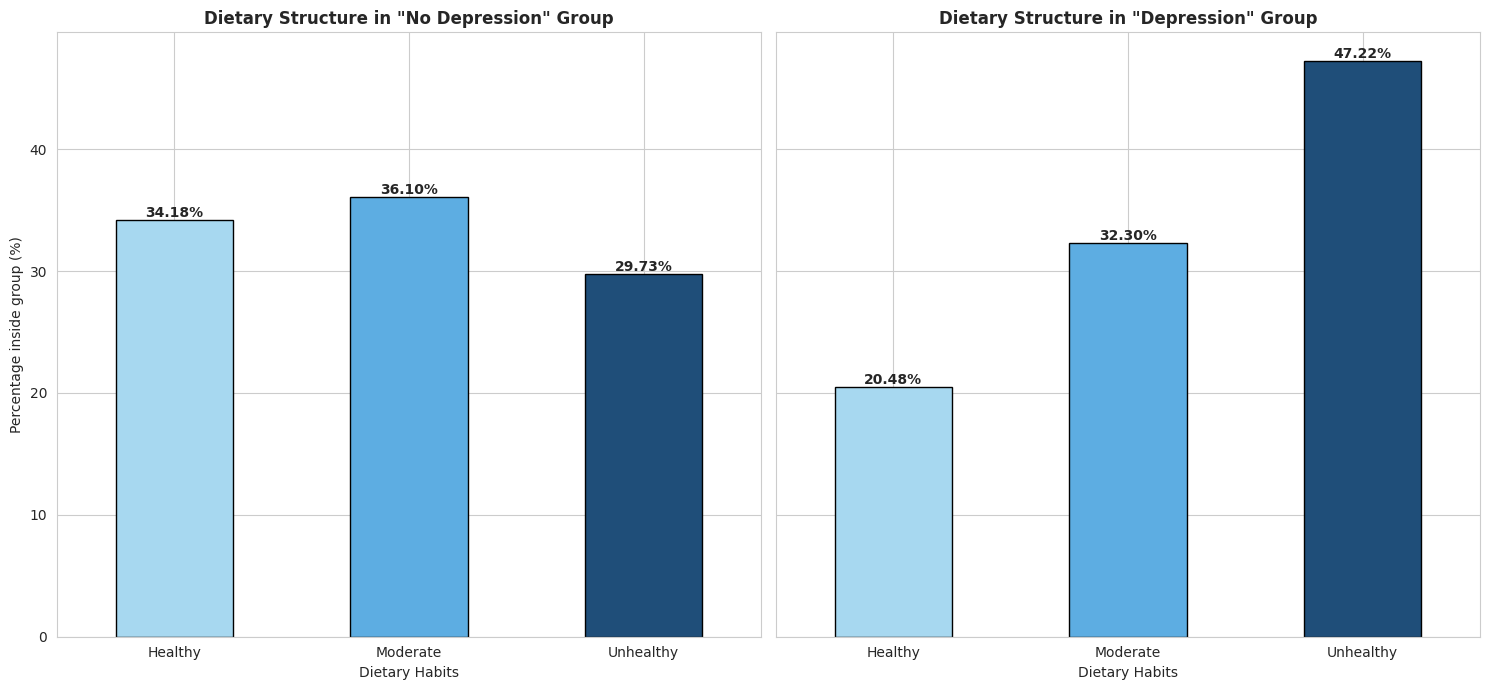

In [8]:
# 1. Tính toán cấu trúc chế độ ăn TRONG NỘI BỘ từng nhóm (Normalize theo cột Depression)
# Tức là: (Số người Healthy bị trầm cảm) / (Tổng số người bị trầm cảm)
diet_structure = pd.crosstab(df['Dietary Habits'], df['Depression'], normalize='columns') * 100

# Đổi tên cột cho rõ ràng
diet_structure.columns = ['No Depression Group', 'Depression Group']

# Sắp xếp thứ tự để thấy trend từ Healthy -> Unhealthy
order = ['Healthy', 'Moderate', 'Unhealthy']
diet_structure = diet_structure.reindex(order)

# 2. Vẽ biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

# Biểu đồ cho nhóm Không trầm cảm
diet_structure['No Depression Group'].plot(kind='bar', ax=ax1, color=['#A7D8F0', '#5DADE2', '#1F4E79'], edgecolor='black')
ax1.set_title('Dietary Structure in "No Depression" Group', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentage inside group (%)')
ax1.tick_params(axis='x', rotation=0)

# Biểu đồ cho nhóm Trầm cảm
diet_structure['Depression Group'].plot(kind='bar', ax=ax2, color=['#A7D8F0', '#5DADE2', '#1F4E79'], edgecolor='black')
ax2.set_title('Dietary Structure in "Depression" Group', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=0)

# Thêm số liệu lên đầu cột
for ax in [ax1, ax2]:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('h1.png')
plt.show()

### Nhận xét
Biểu đồ cho thấy sự khác biệt rõ ràng về cấu trúc chế độ ăn giữa hai nhóm có và không có trầm cảm.

Trong nhóm không trầm cảm, tỷ lệ người có chế độ ăn Healthy và Moderate chiếm phần lớn (lần lượt khoảng 34.18% và 36.10%), trong khi tỷ lệ Unhealthy thấp hơn (29.73%). Điều này cho thấy nhóm này có xu hướng duy trì chế độ ăn uống cân bằng và lành mạnh hơn.

Ngược lại, trong nhóm trầm cảm, tỷ lệ người có chế độ ăn Unhealthy tăng lên đáng kể (47.22%), cao hơn nhiều so với hai nhóm còn lại. Đồng thời, tỷ lệ Healthy giảm xuống còn khoảng 20.48%.

### Insight
Chế độ ăn kém lành mạnh có thể liên quan đến nguy cơ trầm cảm cao hơn, trong khi việc duy trì chế độ ăn lành mạnh có thể góp phần giảm nguy cơ này.


## Câu 2: Số giờ làm/học có liên quan đến trầm cảm không?

Mục tiêu của phân tích này là kiểm tra xem **số giờ làm việc hoặc học tập mỗi ngày (Work/Study Hours)**
có liên quan đến **tình trạng trầm cảm (Depression)** hay không.

Nếu những người bị trầm cảm có xu hướng làm việc/học tập nhiều giờ hơn,
điều đó có thể cho thấy áp lực học tập hoặc công việc là một yếu tố góp phần
làm tăng nguy cơ trầm cảm.

Trong đó cột Work/Study Hours được chia thành các khoảng giá trị (binning) để dễ phân tích và so sánh. Cụ thể:

- 0–5 giờ → Low

- 5–8 giờ → Medium

- 8–12 giờ → High

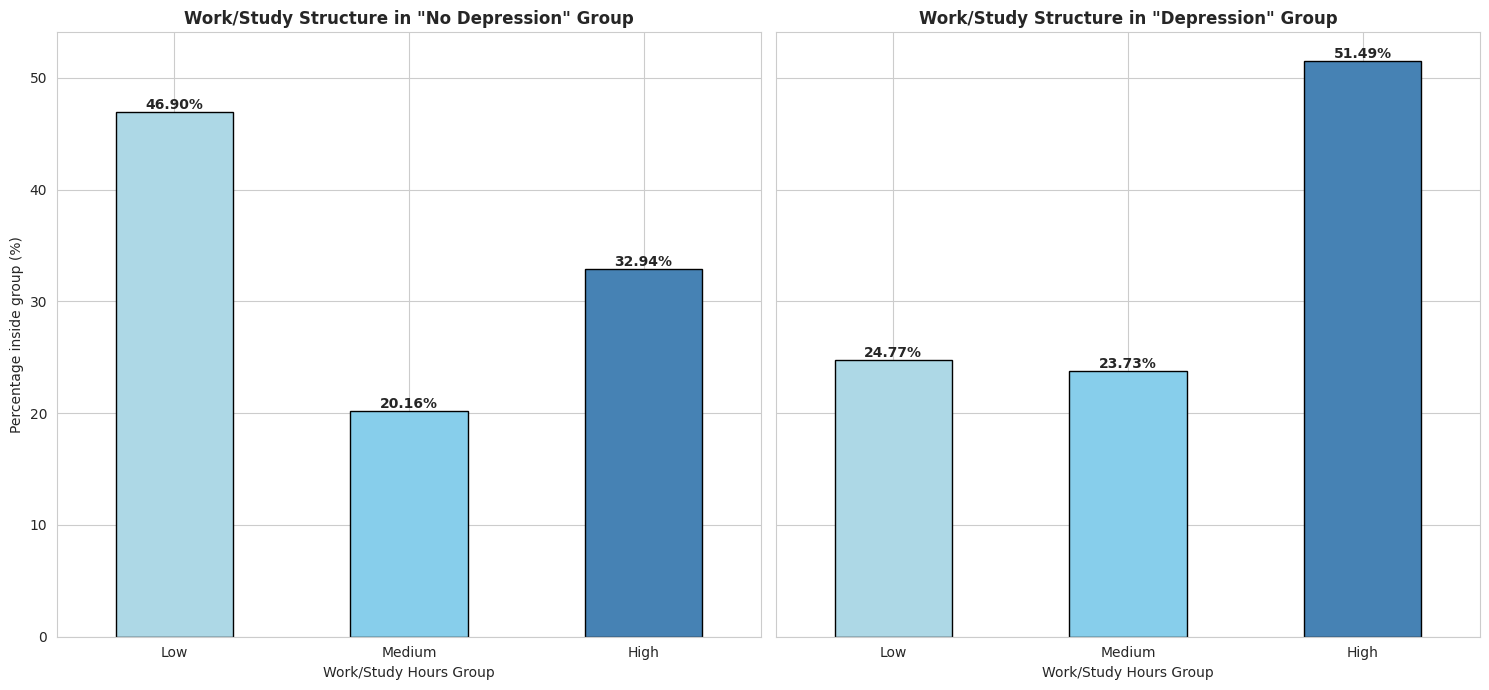

In [9]:
# 1. Phân nhóm Work/Study Hours (giữ nguyên logic của bạn)
bins = [0, 5, 8, 12]
labels = ['Low', 'Medium', 'High']
df['Work/Study Hours Group'] = pd.cut(
    df['Work/Study Hours'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# 2. Tính toán cấu trúc TRONG NỘI BỘ từng nhóm Depression
# Normalize theo 'columns' để xem tỷ trọng Low/Medium/High trong từng nhóm sức khỏe
work_structure = pd.crosstab(df['Work/Study Hours Group'], df['Depression'], normalize='columns') * 100

# Đổi tên cột để biểu đồ rõ nghĩa
work_structure.columns = ['No Depression Group', 'Depression Group']

# Đảm bảo thứ tự Low -> Medium -> High
work_structure = work_structure.reindex(['Low', 'Medium', 'High'])

# 3. Vẽ biểu đồ side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

# Định nghĩa màu sắc (Xanh nhạt -> Xanh đậm để thể hiện mức độ tăng dần)
colors = ['#add8e6', '#87ceeb', '#4682b4']

# Biểu đồ cho nhóm Không trầm cảm
work_structure['No Depression Group'].plot(kind='bar', ax=ax1, color=colors, edgecolor='black')
ax1.set_title('Work/Study Structure in "No Depression" Group', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentage inside group (%)')
ax1.tick_params(axis='x', rotation=0)

# Biểu đồ cho nhóm Trầm cảm
work_structure['Depression Group'].plot(kind='bar', ax=ax2, color=colors, edgecolor='black')
ax2.set_title('Work/Study Structure in "Depression" Group', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=0)

# Thêm % lên đầu cột
for ax in [ax1, ax2]:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('h2_work_trend.png')
plt.show()

### Nhận xét

Biểu đồ cho thấy sự khác biệt đáng kể về cấu trúc thời gian làm việc/học tập giữa hai nhóm có và không có trầm cảm.

Trong nhóm không trầm cảm, phần lớn cá nhân thuộc nhóm Low work/study hours (khoảng 46.90%), trong khi nhóm High hours chiếm 32.94% và Medium hours chiếm tỷ lệ thấp hơn (20.16%). Điều này cho thấy những người không bị trầm cảm có xu hướng dành ít thời gian hơn cho công việc hoặc học tập.

Ngược lại, trong nhóm trầm cảm, tỷ lệ người thuộc nhóm High work/study hours tăng lên đáng kể (51.49%), cao hơn nhiều so với nhóm Low (24.77%) và Medium (23.73%).

### Insight
Việc dành quá nhiều thời gian cho học tập hoặc công việc có thể liên quan đến nguy cơ trầm cảm cao hơn, trong khi việc duy trì khối lượng công việc/học tập ở mức hợp lý có thể giúp giảm nguy cơ này.


## Câu 3: Thời lượng ngủ ảnh hưởng thế nào đến trầm cảm?

Mục tiêu của phân tích này là kiểm tra xem **thời lượng ngủ (Sleep Duration)**
có ảnh hưởng đến **tình trạng trầm cảm (Depression)** hay không?

Liệu những người ngủ quá ít hoặc không đủ giấc có thể dễ gặp
các vấn đề về tâm lý như căng thẳng hoặc trầm cảm hay không?

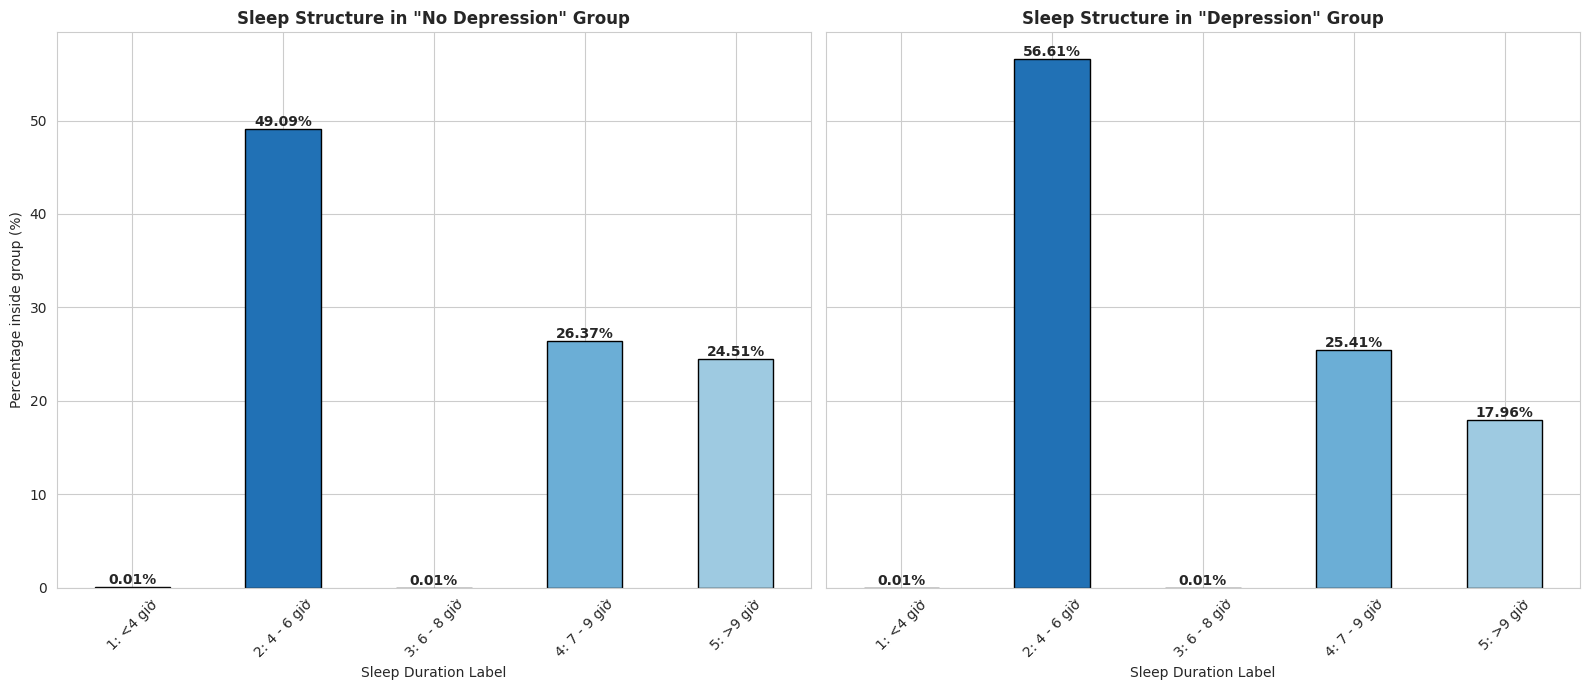

In [10]:
# 1. Mapping và chuẩn bị dữ liệu (Giữ nguyên logic của má)
sleep_labels = {
    1: "1: <4 giờ",
    2: "2: 4 - 6 giờ",
    3: "3: 6 - 8 giờ",
    4: "4: 7 - 9 giờ",
    5: "5: >9 giờ"
}
df['Sleep Duration Label'] = df['Sleep Duration'].map(sleep_labels)
order = list(sleep_labels.values())

# 2. Tính toán cấu trúc nội bộ (Normalize theo cột Depression)
sleep_structure = pd.crosstab(df['Sleep Duration Label'], df['Depression'], normalize='columns') * 100
sleep_structure.columns = ['No Depression Group', 'Depression Group']
sleep_structure = sleep_structure.reindex(order)

# 3. Vẽ biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Đổi sang bảng màu XANH DƯƠNG (từ đậm đến nhạt)
colors = ['#084594', '#2171b5', '#4292c6', '#6baed6', '#9ecae1']

# Biểu đồ cho nhóm Không trầm cảm
sleep_structure['No Depression Group'].plot(kind='bar', ax=ax1, color=colors, edgecolor='black')
ax1.set_title('Sleep Structure in "No Depression" Group', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentage inside group (%)')
ax1.tick_params(axis='x', rotation=45)

# Biểu đồ cho nhóm Trầm cảm
sleep_structure['Depression Group'].plot(kind='bar', ax=ax2, color=colors, edgecolor='black')
ax2.set_title('Sleep Structure in "Depression" Group', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

# Thêm % lên đầu cột
for ax in [ax1, ax2]:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('h3_sleep_blue.png')
plt.show()

### Nhận xét

Biểu đồ cho thấy cấu trúc thời gian ngủ giữa hai nhóm có và không có trầm cảm có sự khác biệt nhưng mà không quá lớm.

Trong cả hai nhóm, phần lớn cá nhân ngủ 4–6 giờ mỗi ngày, nhưng tỷ lệ này cao hơn ở nhóm trầm cảm (56.61% so với 49.09%). Ngược lại, nhóm không trầm cảm có tỷ lệ ngủ trên 9 giờ cao hơn (24.51% so với 17.96%)

### Insight
Việc ngủ không đủ giấc có thể liên quan đến nguy cơ trầm cảm cao nhưng mà không phải là nhân tố quyết định.


### Nhận xét phần I

Khi phân tích từng yếu tố riêng lẻ như **chế độ ăn uống, thời gian làm việc/học tập và thời lượng ngủ**, có thể thấy tỷ lệ trầm cảm có sự thay đổi giữa các nhóm. Tuy nhiên, **mức tăng này không quá lớn**, và trong mọi trường hợp **tỷ lệ không trầm cảm vẫn chiếm đa số**.

Điều này cho thấy mỗi yếu tố riêng lẻ **chỉ làm thay đổi tỷ lệ trầm cảm ở mức nhẹ**, và có thể trầm cảm chịu ảnh hưởng từ **sự kết hợp của nhiều yếu tố**.


## Câu 4: Sự kết hợp hai yếu tố sinh hoạt mang lại nguy cơ mắc bệnh Trầm cảm (Depression) lớn hơn đáng kể so với tác động độc lập không?

Mục tiêu của phân tích này là kiểm tra xem sự kết hợp giữa các cặp thói quen sinh hoạt bao gồm: thời lượng ngủ (Sleep Duration), số giờ làm việc/học tập (Work/Study Hours) và thói quen ăn uống (Dietary Habits) có tạo ra tác động cộng hưởng đến tình trạng trầm cảm (Depression).

Liệu những người làm việc/học tập với cường độ cao, kết hợp với việc thiếu ngủ và ăn uống không lành mạnh, thì nguy cơ rơi vào trầm cảm có tăng vọt (hiệu ứng khuếch đại) so với khi họ chỉ mắc phải một trong những thói quen xấu này hay không?

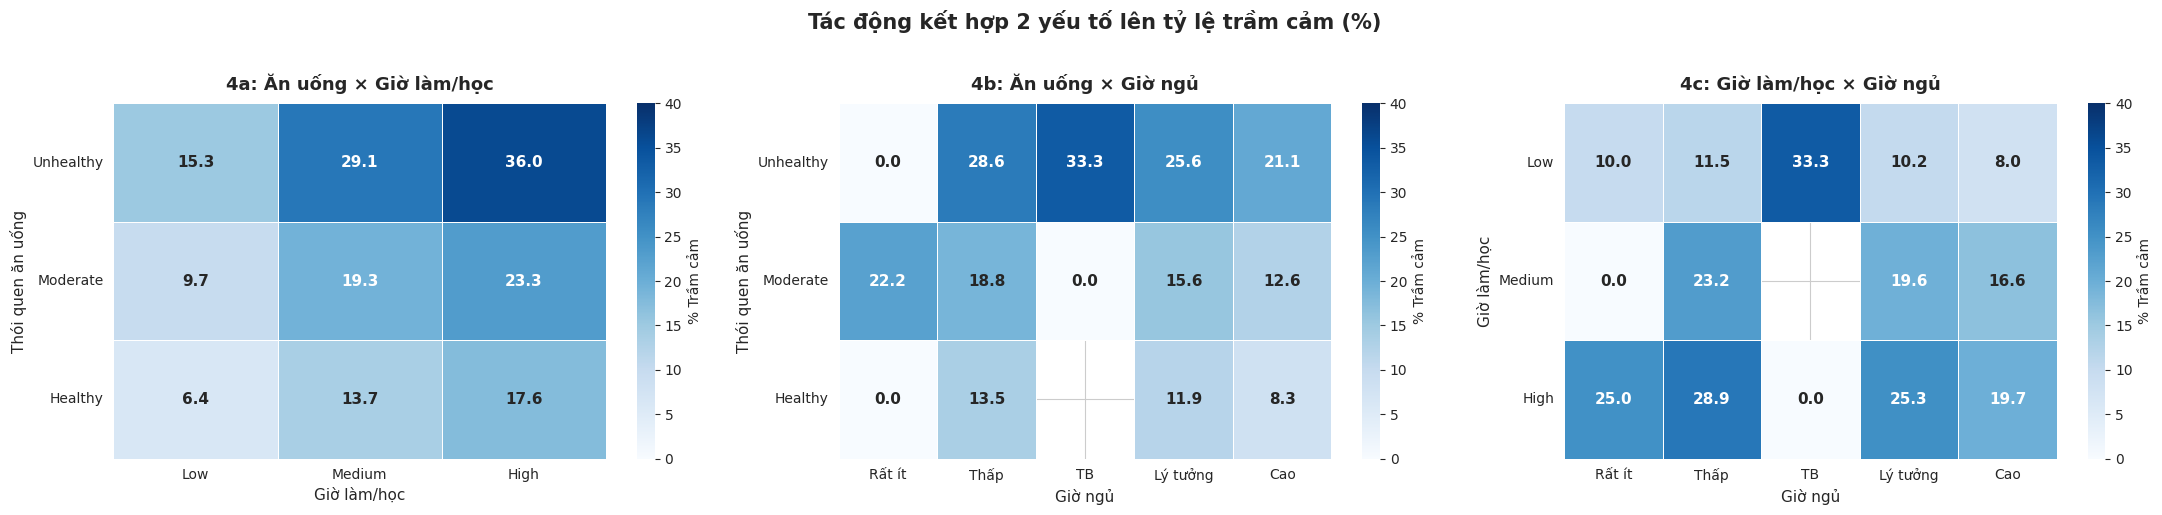

In [ ]:
# 1. Khai báo từ điển
sleep_labels = {
    1: 'Rất ít',
    2: 'Thấp',
    3: 'TB',
    4: 'Lý tưởng',
    5: 'Cao'
}

# 2. Lấy dữ liệu
df['WSH_group'] = df['Work/Study Hours']
df['Sleep_label'] = df['Sleep Duration'].map(sleep_labels)

# 3. Định nghĩa thứ tự hiển thị
diet_order  = ['Unhealthy', 'Moderate', 'Healthy']
wsh_order   = ['Low', 'Medium', 'High']
sleep_order = list(sleep_labels.values())

# 4. Gom nhóm dữ liệu và tính tỷ lệ người mắc bệnh Trầm cảm (% Depression)
pivot_4a = (df.groupby(['Dietary Habits', 'WSH_group'], observed=True)['Depression']
              .mean().unstack()
              .reindex(index=diet_order, columns=wsh_order) * 100)

pivot_4b = (df.groupby(['Dietary Habits', 'Sleep_label'])['Depression']
              .mean().unstack()
              .reindex(index=diet_order, columns=sleep_order) * 100)

pivot_4c = (df.groupby(['WSH_group', 'Sleep_label'], observed=True)['Depression']
              .mean().unstack()
              .reindex(index=wsh_order, columns=sleep_order) * 100)

# 5. Vẽ biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.suptitle('Tác động kết hợp 2 yếu tố lên tỷ lệ trầm cảm (%)',
             fontsize=15, fontweight='bold', y=1.02)

vmin, vmax = 0, 40

def draw_hmap(ax, data, title, xlabel, ylabel):
    sns.heatmap(data, annot=True, fmt='.1f', cmap='Blues',
                vmin=vmin, vmax=vmax, linewidths=0.5, linecolor='white',
                ax=ax, annot_kws={'size': 11, 'weight': 'bold'},
                cbar_kws={'label': '% Trầm cảm'})
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

draw_hmap(axes[0], pivot_4a, '4a: Ăn uống × Giờ làm/học', 'Giờ làm/học', 'Thói quen ăn uống')
draw_hmap(axes[1], pivot_4b, '4b: Ăn uống × Giờ ngủ', 'Giờ ngủ', 'Thói quen ăn uống')
draw_hmap(axes[2], pivot_4c, '4c: Giờ làm/học × Giờ ngủ', 'Giờ ngủ', 'Giờ làm/học')

plt.tight_layout()
plt.show()

### Nhận xét:
Các biểu đồ heatmap cho thấy tỷ lệ trầm cảm luôn đạt mức cao nhất khi các thói quen sinh hoạt tiêu cực xuất hiện cùng lúc:
* **Biểu đồ 4a (Ăn uống × Giờ làm/học):**  Nhóm có chế độ ăn kém (Unhealthy) và cường độ làm việc cao (High) có tỷ lệ trầm cảm cực kỳ cao, lên tới **36.0%**. Ngược lại, nhóm có lối sống lành mạnh nhất (ăn Healthy, làm việc Low) chỉ ở mức **6.4%**.
* **Biểu đồ 4b (Ăn uống × Giờ ngủ):** Sự kết hợp giữa chế độ ăn Unhealthy và thời lượng ngủ Thấp/TB đẩy rủi ro trầm cảm lên mức **28.6% – 33.3%**. Trong khi đó, người ăn Healthy và ngủ Cao chỉ ghi nhận tỷ lệ **8.3%**.
* **Biểu đồ 4c (Giờ làm/học × Giờ ngủ):** Nhóm người vắt kiệt sức với cường độ làm việc High nhưng ngủ Thấp có tỷ lệ trầm cảm là **28.9%**, cao gần gấp 3 lần so với những người làm việc cường độ Low và ngủ Lý tưởng (chỉ **10.2%**). Ngoài ra, ở nhóm làm/học thấp và ngủ Trung bình đạt đến con số **33,33%** là do tỉ lệ mẫu của nhóm này nhỏ (6 người) và có số người mắc trầm cảm là 2 dẫn đến nhiễu dữ liệu.

Kết luận: Sự kết hợp giữa hai yếu tố sinh hoạt xấu mang lại rủi ro mắc bệnh Trầm cảm lớn hơn đáng kể so với tổng các tác động độc lập. Các thói quen này không hoạt động riêng lẻ, mà chúng tương tác và làm trầm trọng thêm hậu quả của nhau đẩy người bệnh vào nguy cơ suy sụp tinh thần với tỷ lệ cao.

## Câu 5: Càng nhiều thói quen xấu thì nguy cơ trầm cảm có càng cao không?

Mục tiêu của phân tích này là kiểm tra xem **số lượng thói quen sinh hoạt không lành mạnh (Bad Habits)**
có ảnh hưởng đến **tình trạng trầm cảm (Depression)** hay không.

Trong phân tích này, thói quen xấu được xác định dựa trên ba yếu tố trong dữ liệu:

- Ngủ quá ít (Sleep Duration ≤ mức thấp, tương ứng dưới khoảng 6 giờ).

- Thời gian học tập/làm việc cao (Work/Study Hours = High).

- Chế độ ăn uống không lành mạnh (Dietary Habits = Unhealthy).

Phân tích này nhằm trả lời câu hỏi: **Liệu khi số lượng thói quen xấu tăng lên, nguy cơ mắc trầm cảm có tăng theo hay không?**

,Number of Bad Habits,No Depression,Depression
0,0,87.863436,12.136564
1,1,81.485351,18.514649
2,2,71.482190,28.517810


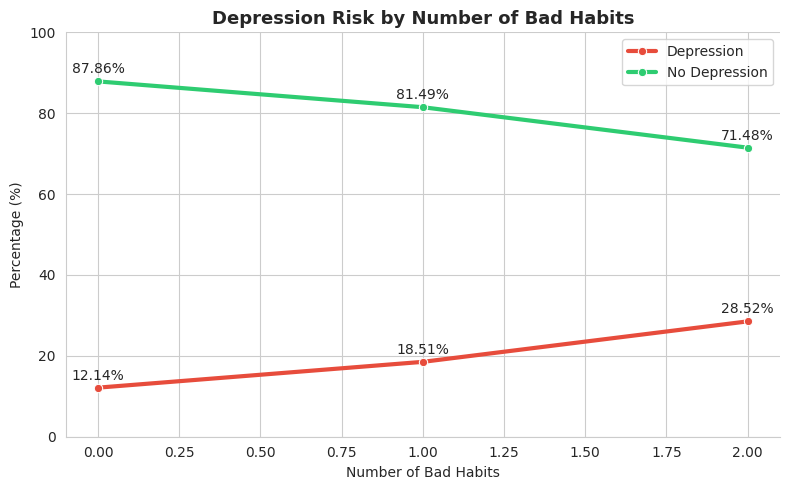

In [11]:
# 1. Tạo các biến thói quen xấu
df['bad_sleep'] = (df['Sleep Duration'] <= 2).astype(int)
df['bad_work'] = (df['Work/Study Hours'] == 'High').astype(int)
df['bad_diet'] = (df['Dietary Habits'] == 'Unhealthy').astype(int)

# 2. Tổng số thói quen xấu
df['bad_habits_count'] = (
    df['bad_sleep'] +
    df['bad_work'] +
    df['bad_diet']
)

# 3. Tính tỷ lệ % trầm cảm trong mỗi mức thói quen xấu
habit_analysis = pd.crosstab(
    df['bad_habits_count'],
    df['Depression'],
    normalize='index'
) * 100

habit_analysis = habit_analysis.reset_index()
habit_analysis.columns = ['Number of Bad Habits','No Depression','Depression']

display(habit_analysis)

# 4. Vẽ biểu đồ
plt.figure(figsize=(8,5))

# Line cho Depression
sns.lineplot(
    data=habit_analysis,
    x='Number of Bad Habits',
    y='Depression',
    marker='o',
    linewidth=3,
    color='#e74c3c',
    label='Depression'
)

# Line cho No Depression
sns.lineplot(
    data=habit_analysis,
    x='Number of Bad Habits',
    y='No Depression',
    marker='o',
    linewidth=3,
    color='#2ecc71',
    label='No Depression'
)

# 5. Thêm % trên từng điểm
for x, y in zip(habit_analysis['Number of Bad Habits'], habit_analysis['Depression']):
    plt.text(x, y + 2, f'{y:.2f}%', ha='center', fontsize=10)

for x, y in zip(habit_analysis['Number of Bad Habits'], habit_analysis['No Depression']):
    plt.text(x, y + 2, f'{y:.2f}%', ha='center', fontsize=10)

# 6. Tùy chỉnh biểu đồ
plt.title('Depression Risk by Number of Bad Habits', fontsize=13, fontweight='bold')
plt.xlabel('Number of Bad Habits')
plt.ylabel('Percentage (%)')
plt.ylim(0,100)

sns.despine()

plt.tight_layout()
plt.savefig('h5_bad_habits_trend.png')
plt.show()

### Nhận xét

Hai đường trong biểu đồ thể hiện xu hướng nghịch chiều rõ ràng giữa tỷ lệ trầm cảm và không trầm cảm khi số lượng thói quen xấu tăng lên. Khi không có thói quen xấu, tỷ lệ trầm cảm chỉ 12.14%, trong khi tỷ lệ không trầm cảm chiếm 87.86%.

Khi xuất hiện 1 thói quen xấu, tỷ lệ trầm cảm tăng lên 18.51%, đồng thời tỷ lệ không trầm cảm giảm xuống 81.49%. Xu hướng này tiếp tục rõ hơn khi số thói quen xấu tăng lên 2, với tỷ lệ trầm cảm đạt 28.52% và tỷ lệ không trầm cảm giảm còn 71.48%.
### Insight
Khi các thói quen sinh hoạt không lành mạnh tích lũy nhiều hơn, nguy cơ trầm cảm có xu hướng tăng lên, trong khi tỷ lệ không trầm cảm giảm dần.

## Kết luận tổng thể

Kết quả phân tích cho thấy **các thói quen sinh hoạt có mối liên hệ nhất định với nguy cơ trầm cảm**.

Khi xem xét từng yếu tố riêng lẻ, mức độ khác biệt không quá lớn. Ta thấy những người có **chế độ ăn uống kém lành mạnh, thời gian làm việc/học tập cao hoặc thời lượng ngủ không phù hợp** thường làm tăng **tỷ lệ trầm cảm** mặc dù không đáng kể so với nhóm người không bị trầm cảm.

Tuy nhiên, khi **nhiều thói quen xấu xuất hiện đồng thời**, tỷ lệ trầm cảm **tăng rõ rệt**. Điều này cho thấy sự kết hợp của nhiều thói quen sinh hoạt không lành mạnh có thể làm gia tăng nguy cơ trầm cảm mạnh hơn so với từng yếu tố riêng lẻ.
